In [1]:
# pip install pandas numpy scikit-learn nltk matplotlib seaborn wordcloud

In [2]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import nltk
from nltk.corpus import stopwords
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
df=pd.read_csv('SMSSpamCollectionDataset', sep='\t', names=['label', 'message'])

In [5]:
df.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [7]:
df.isnull().sum()

label      0
message    0
dtype: int64

In [8]:
# No null values found
# if found can drop or impute
# df.drop(columns='column_name', inplace=True)

In [9]:
df.duplicated().sum()

np.int64(403)

In [10]:
df=df.drop_duplicates(keep='first')

In [11]:
df.rename(columns={'label':'target','message':'text'}, inplace=True)

In [12]:
df.head()

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [13]:
# Label encoder
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['target'] = le.fit_transform(df['target'])
df.head()

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


In [14]:
df.shape

(5169, 2)

In [15]:
values=df['target'].value_counts()
total = values.sum()

percent_0=(df['target'].value_counts()[0]/total)*100
percent_1=(df['target'].value_counts()[1]/total)*100
print("Percentage of non-spam messages:",round(percent_0,2))
print("Percentage of spam messages:",round(percent_1,2))

Percentage of non-spam messages: 87.37
Percentage of spam messages: 12.63


In [16]:
df['num_chars']=df['text'].apply(len)
df['num_words']=df['text'].apply(lambda x: len(nltk.word_tokenize(x.lower())))
df['num_sent']=df['text'].apply(lambda x: len(nltk.sent_tokenize(x.lower())))

df[['num_chars', 'num_words', 'num_sent']].describe()

,num_chars,num_words,num_sent
count,5169.000000,5169.000000,5169.000000
mean,79.344554,18.563358,1.894757
std,58.437457,13.363774,1.386212
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,61.000000,15.000000,1.000000
75%,119.000000,26.000000,2.000000
max,910.000000,216.000000,34.000000


In [17]:
# ham
df[df['target']==0][['num_chars', 'num_words', 'num_sent']].describe()

,num_chars,num_words,num_sent
count,4516.000000,4516.000000,4516.000000
mean,70.905890,17.251771,1.755536
std,56.715046,13.557921,1.321608
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,53.000000,13.000000,1.000000
75%,91.000000,22.000000,2.000000
max,910.000000,216.000000,34.000000


In [18]:
# spam
df[df['target']==1][['num_chars', 'num_words', 'num_sent']].describe()

,num_chars,num_words,num_sent
count,653.000000,653.000000,653.000000
mean,137.704441,27.633997,2.857580
std,29.821348,6.953563,1.439876
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,148.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,223.000000,46.000000,9.000000


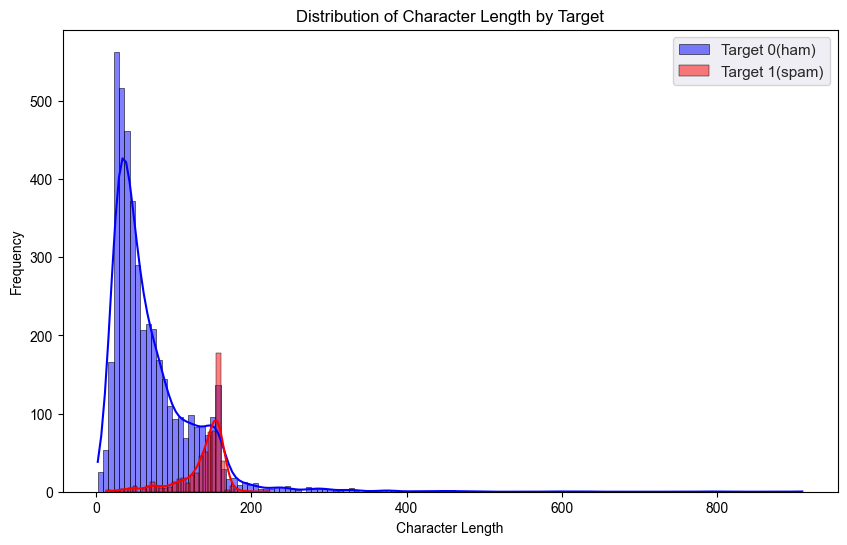

In [19]:
# character length 
plt.figure(figsize=(10, 6))
plt.xlabel('Character Length')
plt.ylabel('Frequency')
plt.title('Distribution of Character Length by Target')
sns.histplot(df[df['target']==0]['num_chars'],color='blue',label='Target 0(ham)',kde=True)
sns.histplot(df[df['target']==1]['num_chars'],color='red',label='Target 1(spam)',kde=True)
sns.set(style='darkgrid')
plt.legend()
plt.show()

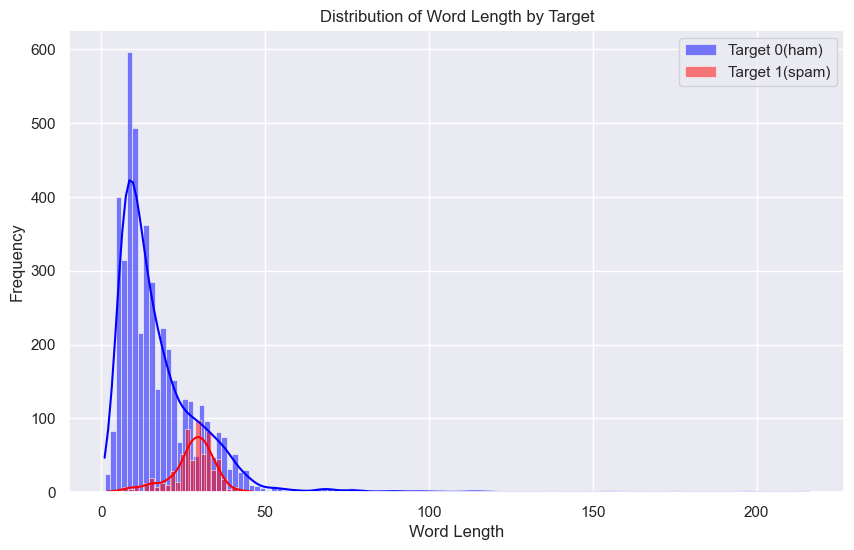

In [20]:
# word length 
plt.figure(figsize=(10, 6))
plt.xlabel('Word Length')
plt.ylabel('Frequency')
plt.title('Distribution of Word Length by Target')
sns.histplot(df[df['target']==0]['num_words'],color='blue',label='Target 0(ham)',kde=True)
sns.histplot(df[df['target']==1]['num_words'],color='red',label='Target 1(spam)',kde=True)
sns.set(style='darkgrid')
plt.legend()
plt.show()

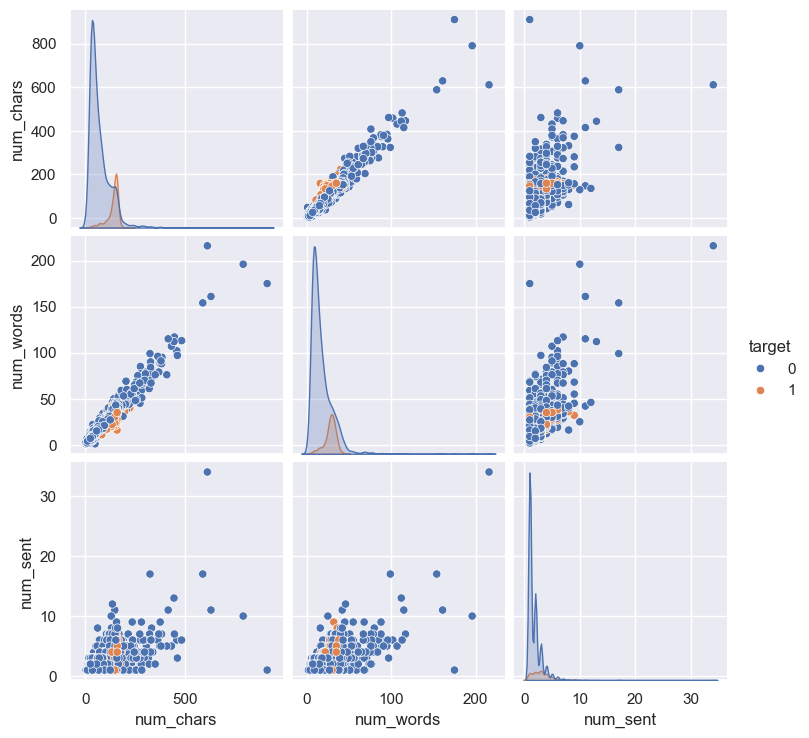

In [21]:
# pairplot
sns.pairplot(df,hue='target')
plt.show()

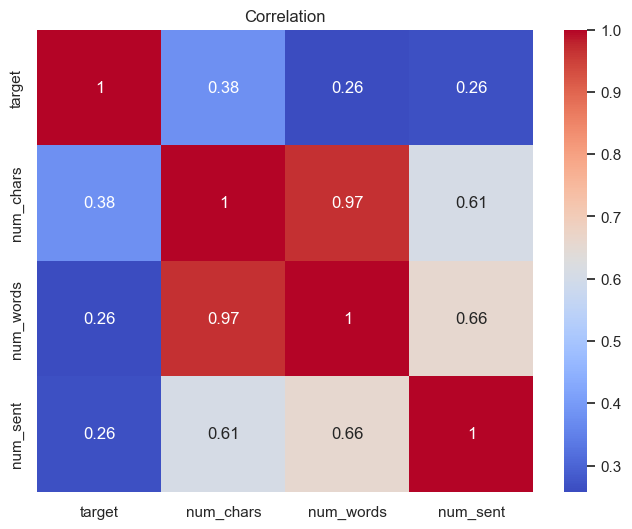

In [22]:
#correlation matrix
correlation_matrix=df[['target','num_chars', 'num_words', 'num_sent']].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation')
plt.show()

**Data Preprocessing**

In [ ]:
from nltk import PorterStemmer

import string
ps=PorterStemmer()

def preprocess(text):
    text=text.lower()
    text=nltk.word_tokenize(text) #tokenizing
    y=[]
    for i in text: #remove non-alphanumeric from every word
        if i.isalnum():
            y.append(i)
    text=y[:] 
    y.clear()
    for i in text: #remove stopwords
        if i not in stopwords.words('english') and i not in string.punctuation:
            y.append(i)
    text=y[:] 
    y.clear()
    for i in text: #stemming
        y.append(ps.stem(i))
    return " ".join(y)

In [24]:
preprocess('Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...')

'go jurong point crazi avail bugi n great world la e buffet cine got amor wat'

In [25]:
df['transformed_text']=df['text'].apply(preprocess)

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14428\2683107060.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filter_spam_df,x=filter_spam_df[0], y=filter_spam_df[1],palette='brg')


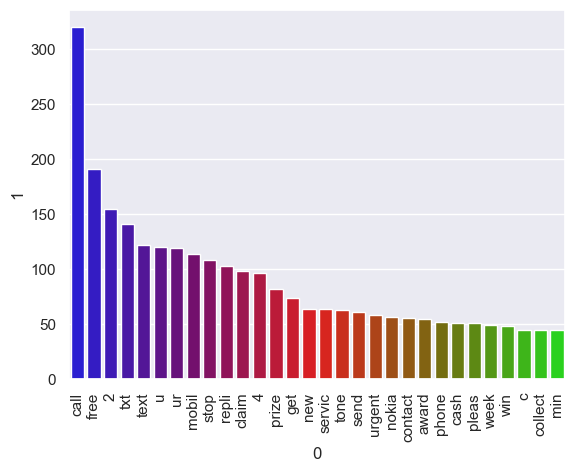

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_14428\2683107060.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=filter_ham_df,x=filter_ham_df[0], y=filter_ham_df[1],palette='cool')


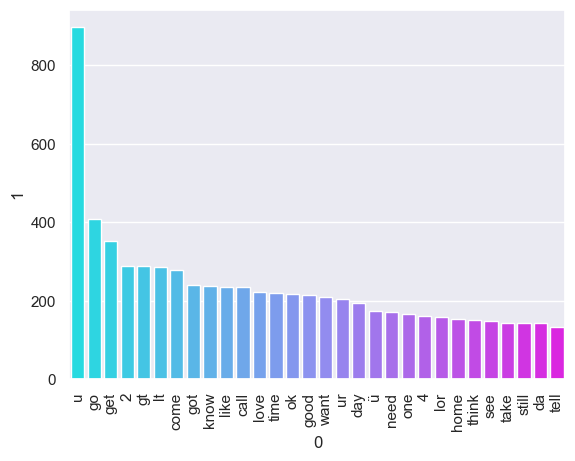

In [26]:
#

from collections import Counter

spam_carpos = []
for sentence in df[df['target']==1]['transformed_text'].tolist():
    for word in sentence.split():
        spam_carpos.append(word)
filter_spam_df = pd.DataFrame(Counter(spam_carpos).most_common(30))
sns.barplot(data=filter_spam_df,x=filter_spam_df[0], y=filter_spam_df[1],palette='brg')
plt.xticks(rotation=90)
plt.show()

ham_carpos = []
for sentence in df[df['target']==0]['transformed_text'].tolist():
    for word in sentence.split():
        ham_carpos.append(word)
filter_ham_df = pd.DataFrame(Counter(ham_carpos).most_common(30))
sns.barplot(data=filter_ham_df,x=filter_ham_df[0], y=filter_ham_df[1],palette='cool')
plt.xticks(rotation=90)
plt.show()

In [27]:
# feature extraction
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
cv=CountVectorizer()
tfidf=TfidfVectorizer()

X=cv.fit_transform(df['transformed_text']).toarray()
y=df['target']

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [29]:
#optional
print(len(X)*0.8) #80% of total data for training
print(len(X)*0.2) #20% of total data for testing


4135.2
1033.8


In [30]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(4135, 6782)
(4135,)
(1034, 6782)
(1034,)


**Importing the models**

In [31]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: C:\Users\Lenovo\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from xgboost import XGBClassifier

**Initialize the models**

In [33]:
svc=SVC(kernel='sigmoid',gamma=1.0)
knc=KNeighborsClassifier()
mnb=MultinomialNB()
lrc=LogisticRegression(solver='liblinear',penalty='l1')
dtc=DecisionTreeClassifier(max_depth=5)
rfc=RandomForestClassifier(n_estimators=50,random_state=42)
gbc=GradientBoostingClassifier(n_estimators=50,random_state=42)
abc=AdaBoostClassifier(n_estimators=50,random_state=42)
etc=ExtraTreesClassifier(n_estimators=50,random_state=42)
bc=BaggingClassifier(n_estimators=50,random_state=42)
xgb=XGBClassifier(n_estimators=50,random_state=42)

In [34]:
#creating dictionary for models
models={'svc':svc,'knc':knc,'mnb':mnb,'lrc':lrc,'dtc':dtc,'rfc':rfc,'gbc':gbc,'abc':abc,'etc':etc,'bc':bc,'xgb':xgb}

In [ ]:
# train and fit the model

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def train_model(models,X_train,y_train,X_test,y_test):
    models.fit(X_train,y_train)
    y_pred=models.predict(X_test)

    accuracy=accuracy_score(y_test,y_pred)
    precision=precision_score(y_test,y_pred)
    recall=recall_score(y_test,y_pred)
    f1=f1_score(y_test,y_pred)
    cm=confusion_matrix(y_test,y_pred)

    return accuracy, precision, recall, f1, cm

In [40]:
accuracy_scores=[]
precision_scores=[]
recall_scores=[]
f1_scores=[]
confusion_matrices=[]

best_model = None
best_f1 = 0

for name, model in models.items():
    curr_acc, curr_prec, curr_rec, curr_f1, curr_cm = train_model(model, X_train, y_train, X_test, y_test)
    print()
    print("For:",name)
    print("Accuracy:",curr_acc)
    print("Precision:",curr_prec)
    print("Recall:",curr_rec)
    print("F1-Score:",curr_f1)
    print("Confusion Matrix:",curr_cm)

    accuracy_scores.append(curr_acc)
    precision_scores.append(curr_prec)
    recall_scores.append(curr_rec)
    f1_scores.append(curr_f1)
    confusion_matrices.append(curr_cm)

    if curr_f1 > best_f1:
        best_f1 = curr_f1
        best_model = model

print()
print('='*32)
print("Best Model:", best_model)
print("Best F1-Score:", best_f1)
print('='*32)


For: svc
Accuracy: 0.9274661508704062
Precision: 0.7642276422764228
Recall: 0.6714285714285714
F1-Score: 0.714828897338403
Confusion Matrix: [[865  29]
 [ 46  94]]

For: knc
Accuracy: 0.9081237911025145
Precision: 0.9787234042553191
Recall: 0.32857142857142857
F1-Score: 0.4919786096256685
Confusion Matrix: [[893   1]
 [ 94  46]]

For: mnb
Accuracy: 0.9729206963249516
Precision: 0.868421052631579
Recall: 0.9428571428571428
F1-Score: 0.9041095890410958
Confusion Matrix: [[874  20]
 [  8 132]]

For: lrc
Accuracy: 0.9777562862669246
Precision: 0.975609756097561
Recall: 0.8571428571428571
F1-Score: 0.9125475285171103
Confusion Matrix: [[891   3]
 [ 20 120]]

For: dtc
Accuracy: 0.9284332688588007
Precision: 0.9583333333333334
Recall: 0.4928571428571429
F1-Score: 0.6509433962264151
Confusion Matrix: [[891   3]
 [ 71  69]]

For: rfc
Accuracy: 0.9690522243713733
Precision: 1.0
Recall: 0.7714285714285715
F1-Score: 0.8709677419354839
Confusion Matrix: [[894   0]
 [ 32 108]]

For: gbc
Accuracy: 0

C:\Users\Lenovo\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(



For: abc
Accuracy: 0.9632495164410058
Precision: 0.9180327868852459
Recall: 0.8
F1-Score: 0.8549618320610687
Confusion Matrix: [[884  10]
 [ 28 112]]

For: etc
Accuracy: 0.9738878143133463
Precision: 1.0
Recall: 0.8071428571428572
F1-Score: 0.8932806324110671
Confusion Matrix: [[894   0]
 [ 27 113]]

For: bc
Accuracy: 0.9661508704061895
Precision: 0.9646017699115044
Recall: 0.7785714285714286
F1-Score: 0.8616600790513834
Confusion Matrix: [[890   4]
 [ 31 109]]

For: xgb
Accuracy: 0.971953578336557
Precision: 0.9743589743589743
Recall: 0.8142857142857143
F1-Score: 0.8871595330739299
Confusion Matrix: [[891   3]
 [ 26 114]]

Best Model: LogisticRegression(penalty='l1', solver='liblinear')
Best F1-Score: 0.9125475285171103


In [ ]:
example_input = ["Hello world! How are you?"]
input_transformed = cv.transform(example_input).toarray()
for text in input_transformed:
    print('='*32)
    print("Text:",text)
    print("Predicted Label:",best_model.predict([text])[0])

    if best_model.predict([text])[0]==0:
        print("****(( Ham ))****")
    else:
        print("****(( Spam ))****")

    print('='*32)
    print()

Text: [0 0 0 ... 0 0 0]
Predicted Label: 0
****(( Ham ))****

